### Cell 1 — Imports


In [100]:
from __future__ import annotations
from IPython.display import display, Image

import json
import logging
import random
import shutil
import time
from pathlib import Path
from typing import Any, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

### Cell 2 — Configuration

In [101]:
CONFIG = {
    "project_root": "/home/iailab42/khans1/projects",
    "seed": 42,

    "data": {
        "real_data_dir": "data",
        "input_x_file": "all_X.npy",
        "input_y_file": "all_y.npy",
        "input_subject_file": "all_subject.npy",
        "normalization_stats_file": "normalization_stats.npz",
        "expected_seq_len": 512,
        "expected_num_channels": 6,
        "target_hz": 64,
        "window_len": 512,
        "shift_len": 128,
        "channel_names": ["ACC_x", "ACC_y", "ACC_z", "BVP", "EDA", "TEMP"],
    },

    "model": {
        "model_name": "timevae_conditional_6ch_v2",
        "latent_dim": 128,
        "label_embedding_dim": 32,
        "hidden_dims": [128, 256, 256],
        "encoder_dense_dim": 512,
        "reconstruction_weight": 10.0,
        "temporal_weight": 2.0,
        "kl_weight": 1e-6,
    },

    "training": {
        "batch_size": 128,
        "epochs": 100,
        "learning_rate": 1e-3,
        "weight_decay": 1e-5,
        "val_fraction": 0.10,
        "patience": 12,
        "min_delta": 1e-5,
        "num_workers": 0,
        "force_retrain": False,
    },

    "generation": {
        "synthetic_multiplier": 1.0,
        "synthetic_subject_count": 30,
        "generation_batch_size": 512,
    },

    "outputs": {
        "save_diagnostic_plots": True,
    },
}


PROJECT_ROOT = Path(CONFIG["project_root"])

PATHS = {
    "real_data_dir": PROJECT_ROOT / CONFIG["data"]["real_data_dir"],

    "synthetic_dir": PROJECT_ROOT / "data" / "synthetic" / "timevae",
    "model_dir": PROJECT_ROOT / "models" / "timevae",
    "results_dir": PROJECT_ROOT / "results" / "timevae",
    "figures_dir": PROJECT_ROOT / "figures" / "timevae",
    "configs_dir": PROJECT_ROOT / "configs" / "timevae",
    "logs_dir": PROJECT_ROOT / "logs" / "timevae",

    "model_file": PROJECT_ROOT / "models" / "timevae" / "timevae_conditional_6ch.pt",
    "config_file": PROJECT_ROOT / "configs" / "timevae" / "timevae_config.json",
    "label_map_file": PROJECT_ROOT / "configs" / "timevae" / "timevae_label_map.json",
    "log_file": PROJECT_ROOT / "logs" / "timevae" / "timevae_run.log",
}

### Cell 3 — Utilities

In [102]:
def create_timevae_folders(paths: Dict[str, Path]) -> None:
    for key in [
        "synthetic_dir",
        "model_dir",
        "results_dir",
        "figures_dir",
        "configs_dir",
        "logs_dir",
    ]:
        paths[key].mkdir(parents=True, exist_ok=True)


def setup_logger(log_path: Path) -> logging.Logger:
    logger = logging.getLogger("timevae")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    file_handler = logging.FileHandler(log_path)
    file_handler.setFormatter(formatter)

    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)

    logger.addHandler(file_handler)
    logger.addHandler(stream_handler)

    return logger


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True


def to_jsonable(value: Any) -> Any:
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(k): to_jsonable(v) for k, v in value.items()}
    if isinstance(value, list):
        return [to_jsonable(v) for v in value]
    return value


def save_json(data: Dict[str, Any], path: Path, overwrite: bool = True) -> None:
    if path.exists() and not overwrite:
        return

    path.parent.mkdir(parents=True, exist_ok=True)

    with path.open("w", encoding="utf-8") as f:
        json.dump(to_jsonable(data), f, indent=4)


create_timevae_folders(PATHS)
set_seed(CONFIG["seed"])

logger = setup_logger(PATHS["log_file"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

save_json(
    {"config": CONFIG, "paths": PATHS},
    PATHS["config_file"],
    overwrite=True,
)

logger.info(f"Using device: {device}")
logger.info("TimeVAE setup complete.")

2026-06-14 23:06:49 | INFO | Using device: cuda
2026-06-14 23:06:49 | INFO | TimeVAE setup complete.


### Cell 4 — Load Real Preprocessed Data

In [103]:
def load_preprocessed_data(
    config: Dict[str, Any],
    paths: Dict[str, Path],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    data_dir = paths["real_data_dir"]

    x_path = data_dir / config["data"]["input_x_file"]
    y_path = data_dir / config["data"]["input_y_file"]
    subject_path = data_dir / config["data"]["input_subject_file"]

    if not x_path.exists():
        raise FileNotFoundError(f"Missing file: {x_path}")
    if not y_path.exists():
        raise FileNotFoundError(f"Missing file: {y_path}")
    if not subject_path.exists():
        raise FileNotFoundError(f"Missing file: {subject_path}")

    X = np.load(x_path, allow_pickle=False).astype(np.float32)
    y = np.load(y_path, allow_pickle=True)
    subjects = np.load(subject_path, allow_pickle=True)

    if X.ndim != 3:
        raise ValueError(f"Expected X shape [N, T, D], got {X.shape}")

    expected_seq_len = config["data"]["expected_seq_len"]
    expected_channels = config["data"]["expected_num_channels"]

    if X.shape[1] != expected_seq_len:
        raise ValueError(f"Expected sequence length {expected_seq_len}, got {X.shape[1]}")

    if X.shape[2] != expected_channels:
        raise ValueError(f"Expected {expected_channels} channels, got {X.shape[2]}")

    if len(X) != len(y) or len(X) != len(subjects):
        raise ValueError(
            f"Length mismatch: X={len(X)}, y={len(y)}, subjects={len(subjects)}"
        )

    if not np.all(np.isfinite(X)):
        raise ValueError("X contains NaN or infinite values.")

    return X, y, subjects


X_real, y_real, subjects_real = load_preprocessed_data(CONFIG, PATHS)

logger.info(f"X_real shape: {X_real.shape}")
logger.info(f"y_real shape: {y_real.shape}")
logger.info(f"subjects_real shape: {subjects_real.shape}")
logger.info(f"Unique activity labels: {np.unique(y_real)}")
logger.info(f"Unique subjects: {np.unique(subjects_real)}")

label_counts = pd.Series(np.asarray(y_real).reshape(-1)).value_counts().sort_index()
label_counts

2026-06-14 23:06:50 | INFO | X_real shape: (46907, 512, 6)
2026-06-14 23:06:50 | INFO | y_real shape: (46907,)
2026-06-14 23:06:50 | INFO | subjects_real shape: (46907,)
2026-06-14 23:06:50 | INFO | Unique activity labels: [1 2 3 4 5 6 7 8]
2026-06-14 23:06:50 | INFO | Unique subjects: ['S1' 'S10' 'S11' 'S12' 'S13' 'S14' 'S15' 'S2' 'S3' 'S4' 'S5' 'S6' 'S7'
 'S8' 'S9']


1     4534
2     3205
3     2277
4     3439
5     6807
6    13518
7     4660
8     8467
Name: count, dtype: int64

### Cell 5 — Label Encoding

In [104]:
def normalize_label_array(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y)

    if y.ndim == 2 and y.shape[1] == 1:
        y = y[:, 0]
    elif y.ndim != 1:
        raise ValueError(f"Expected y as [N] or [N, 1], got {y.shape}")

    return y


def create_label_mapping(
    y: np.ndarray,
) -> Tuple[np.ndarray, Dict[int, int], Dict[int, int]]:
    y_flat = normalize_label_array(y).astype(int)

    unique_original_labels = sorted(np.unique(y_flat).tolist())

    label_to_index = {
        int(label): int(idx)
        for idx, label in enumerate(unique_original_labels)
    }

    index_to_label = {
        int(idx): int(label)
        for label, idx in label_to_index.items()
    }

    y_index = np.array(
        [label_to_index[int(label)] for label in y_flat],
        dtype=np.int64,
    )

    return y_index, label_to_index, index_to_label


y_index, label_to_index, index_to_label = create_label_mapping(y_real)
num_classes = len(label_to_index)

label_map_data = {
    "label_to_index": label_to_index,
    "index_to_label": index_to_label,
    "num_classes": num_classes,
}

save_json(label_map_data, PATHS["label_map_file"], overwrite=True)

logger.info(f"Number of activity classes: {num_classes}")
logger.info(f"Label mapping: {label_to_index}")

pd.DataFrame({
    "original_label": list(label_to_index.keys()),
    "internal_model_label": list(label_to_index.values()),
})

2026-06-14 23:06:50 | INFO | Number of activity classes: 8
2026-06-14 23:06:50 | INFO | Label mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}


,original_label,internal_model_label
0,1,0
1,2,1
2,3,2
3,4,3
4,5,4
5,6,5
6,7,6
7,8,7


### Cell 6 — Train/Validation Split

In [105]:
def make_train_val_indices(
    n_samples: int,
    val_fraction: float,
    seed: int,
) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)

    indices = np.arange(n_samples)
    rng.shuffle(indices)

    n_val = int(round(n_samples * val_fraction))
    n_val = max(1, n_val)

    val_indices = indices[:n_val]
    train_indices = indices[n_val:]

    if len(train_indices) == 0:
        raise ValueError("Training set is empty. Reduce val_fraction.")

    return train_indices, val_indices


train_indices, val_indices = make_train_val_indices(
    n_samples=len(X_real),
    val_fraction=CONFIG["training"]["val_fraction"],
    seed=CONFIG["seed"],
)

logger.info(f"Train windows: {len(train_indices)}")
logger.info(f"Validation windows: {len(val_indices)}")

2026-06-14 23:06:50 | INFO | Train windows: 42216
2026-06-14 23:06:50 | INFO | Validation windows: 4691


### Cell 7 — Data Loaders


In [106]:
def create_data_loaders(
    X: np.ndarray,
    y_idx: np.ndarray,
    train_indices: np.ndarray,
    val_indices: np.ndarray,
    config: Dict[str, Any],
) -> Tuple[DataLoader, DataLoader]:
    X_tensor = torch.from_numpy(X.astype(np.float32))
    y_tensor = torch.from_numpy(y_idx.astype(np.int64))

    train_dataset = TensorDataset(
        X_tensor[train_indices],
        y_tensor[train_indices],
    )

    val_dataset = TensorDataset(
        X_tensor[val_indices],
        y_tensor[val_indices],
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["training"]["batch_size"],
        shuffle=True,
        num_workers=config["training"]["num_workers"],
        drop_last=False,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["training"]["batch_size"],
        shuffle=False,
        num_workers=config["training"]["num_workers"],
        drop_last=False,
    )

    return train_loader, val_loader


train_loader, val_loader = create_data_loaders(
    X=X_real,
    y_idx=y_index,
    train_indices=train_indices,
    val_indices=val_indices,
    config=CONFIG,
)

logger.info("DataLoaders created.")

2026-06-14 23:06:50 | INFO | DataLoaders created.


### Cell 8 — Conditional TimeVAE Model

In [107]:
class ConditionalTimeVAE(nn.Module):
    def __init__(
        self,
        seq_len: int,
        input_dim: int,
        num_classes: int,
        latent_dim: int,
        label_embedding_dim: int,
        hidden_dims: list[int],
        encoder_dense_dim: int,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.latent_dim = latent_dim
        self.label_embedding_dim = label_embedding_dim
        self.hidden_dims = hidden_dims
        self.encoder_dense_dim = encoder_dense_dim

        self.label_embedding = nn.Embedding(num_classes, label_embedding_dim)

        encoder_layers = []
        in_channels = input_dim

        for hidden_dim in hidden_dims:
            encoder_layers.append(
                nn.Sequential(
                    nn.Conv1d(
                        in_channels=in_channels,
                        out_channels=hidden_dim,
                        kernel_size=4,
                        stride=2,
                        padding=1,
                    ),
                    nn.BatchNorm1d(hidden_dim),
                    nn.ReLU(),
                )
            )
            in_channels = hidden_dim

        self.encoder_conv = nn.Sequential(*encoder_layers)

        with torch.no_grad():
            dummy = torch.zeros(1, input_dim, seq_len)
            encoded = self.encoder_conv(dummy)
            self.encoded_shape = encoded.shape[1:]
            self.flatten_dim = int(np.prod(self.encoded_shape))

        self.encoder_dense = nn.Sequential(
            nn.Linear(self.flatten_dim + label_embedding_dim, encoder_dense_dim),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(encoder_dense_dim, latent_dim)
        self.fc_logvar = nn.Linear(encoder_dense_dim, latent_dim)

        self.decoder_dense = nn.Sequential(
            nn.Linear(latent_dim + label_embedding_dim, self.flatten_dim),
            nn.ReLU(),
        )

        reversed_dims = list(reversed(hidden_dims))

        decoder_layers = []

        for i in range(len(reversed_dims) - 1):
            decoder_layers.append(
                nn.Sequential(
                    nn.ConvTranspose1d(
                        in_channels=reversed_dims[i],
                        out_channels=reversed_dims[i + 1],
                        kernel_size=4,
                        stride=2,
                        padding=1,
                    ),
                    nn.BatchNorm1d(reversed_dims[i + 1]),
                    nn.ReLU(),
                )
            )

        self.decoder_deconv = nn.Sequential(*decoder_layers)

        self.output_layer = nn.ConvTranspose1d(
            in_channels=reversed_dims[-1],
            out_channels=input_dim,
            kernel_size=4,
            stride=2,
            padding=1,
        )

    def encode(
        self,
        x: torch.Tensor,
        y: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        x = x.transpose(1, 2)

        h = self.encoder_conv(x)
        h = h.reshape(h.size(0), -1)

        y_emb = self.label_embedding(y)
        h = torch.cat([h, y_emb], dim=1)

        h = self.encoder_dense(h)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(
        self,
        mu: torch.Tensor,
        logvar: torch.Tensor,
    ) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(
        self,
        z: torch.Tensor,
        y: torch.Tensor,
    ) -> torch.Tensor:
        y_emb = self.label_embedding(y)

        h = torch.cat([z, y_emb], dim=1)
        h = self.decoder_dense(h)
        h = h.view(z.size(0), *self.encoded_shape)

        h = self.decoder_deconv(h)
        x_recon = self.output_layer(h)

        if x_recon.shape[-1] != self.seq_len:
            x_recon = F.interpolate(
                x_recon,
                size=self.seq_len,
                mode="linear",
                align_corners=False,
            )

        return x_recon.transpose(1, 2)

    def forward(
        self,
        x: torch.Tensor,
        y: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, y)

        return x_recon, mu, logvar

### Cell 9 — Loss and Model Helpers

In [108]:
def timevae_loss(
    x_recon: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    reconstruction_weight: float,
    kl_weight: float,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    mse_loss = F.mse_loss(x_recon, x, reduction="mean")
    l1_loss = F.l1_loss(x_recon, x, reduction="mean")

    real_diff = x[:, 1:, :] - x[:, :-1, :]
    recon_diff = x_recon[:, 1:, :] - x_recon[:, :-1, :]

    temporal_loss = F.mse_loss(recon_diff, real_diff, reduction="mean")

    reconstruction_loss = (
        mse_loss
        + 0.5 * l1_loss
        + CONFIG["model"]["temporal_weight"] * temporal_loss
    )

    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    total_loss = reconstruction_weight * reconstruction_loss + kl_weight * kl_loss

    return total_loss, reconstruction_loss, kl_loss

### Cell 10 — Training Functions

In [109]:
def run_one_epoch(
    model: ConditionalTimeVAE,
    data_loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
    config: Dict[str, Any],
) -> Dict[str, float]:
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss_sum = 0.0
    reconstruction_loss_sum = 0.0
    kl_loss_sum = 0.0
    n_batches = 0

    for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            x_recon, mu, logvar = model(x_batch, y_batch)

            total_loss, reconstruction_loss, kl_loss = timevae_loss(
                x_recon=x_recon,
                x=x_batch,
                mu=mu,
                logvar=logvar,
                reconstruction_weight=config["model"]["reconstruction_weight"],
                kl_weight=config["model"]["kl_weight"],
            )

            if is_training:
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        total_loss_sum += float(total_loss.item())
        reconstruction_loss_sum += float(reconstruction_loss.item())
        kl_loss_sum += float(kl_loss.item())
        n_batches += 1

    return {
        "loss": total_loss_sum / max(n_batches, 1),
        "reconstruction_loss": reconstruction_loss_sum / max(n_batches, 1),
        "kl_loss": kl_loss_sum / max(n_batches, 1),
    }


def train_or_load_timevae(
    X: np.ndarray,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: Dict[str, Any],
    paths: Dict[str, Path],
    label_to_index: Dict[int, int],
    index_to_label: Dict[int, int],
    train_indices: np.ndarray,
    val_indices: np.ndarray,
    device: torch.device,
    logger: logging.Logger,
) -> Tuple[ConditionalTimeVAE, Dict[str, Any], bool]:
    model_path = paths["model_file"]

    if model_path.exists() and not config["training"]["force_retrain"]:
        logger.info(f"Existing TimeVAE model found. Loading: {model_path}")

        model, checkpoint = load_checkpoint(model_path, device)

        return model, checkpoint, False

    logger.info("No existing model found, or force_retrain=True. Training TimeVAE.")

    model = build_model(
        config=config,
        seq_len=X.shape[1],
        input_dim=X.shape[2],
        num_classes=len(label_to_index),
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["training"]["learning_rate"],
        weight_decay=config["training"]["weight_decay"],
    )

    best_val_loss = float("inf")
    best_epoch = -1
    patience_counter = 0
    history = []

    start_time = time.time()

    for epoch in range(1, config["training"]["epochs"] + 1):
        train_metrics = run_one_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            device=device,
            config=config,
        )

        val_metrics = run_one_epoch(
            model=model,
            data_loader=val_loader,
            optimizer=None,
            device=device,
            config=config,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_reconstruction_loss": train_metrics["reconstruction_loss"],
            "train_kl_loss": train_metrics["kl_loss"],
            "val_loss": val_metrics["loss"],
            "val_reconstruction_loss": val_metrics["reconstruction_loss"],
            "val_kl_loss": val_metrics["kl_loss"],
        }

        history.append(row)

        improved = val_metrics["loss"] < best_val_loss - config["training"]["min_delta"]

        if improved:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            patience_counter = 0

            save_checkpoint(
                model=model,
                optimizer=optimizer,
                path=model_path,
                config=config,
                label_to_index=label_to_index,
                index_to_label=index_to_label,
                history=history,
                train_indices=train_indices,
                val_indices=val_indices,
            )
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 10 == 0 or improved:
            logger.info(
                f"Epoch {epoch:03d} | "
                f"train_loss={train_metrics['loss']:.6f} | "
                f"val_loss={val_metrics['loss']:.6f} | "
                f"best_val_loss={best_val_loss:.6f}"
            )

        if patience_counter >= config["training"]["patience"]:
            logger.info(
                f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}"
            )
            break

    training_time = time.time() - start_time

    model, checkpoint = load_checkpoint(model_path, device)

    checkpoint["training_time_seconds"] = training_time
    checkpoint["best_epoch"] = best_epoch
    checkpoint["best_val_loss"] = best_val_loss

    logger.info(
        f"Training finished. Best epoch={best_epoch}, "
        f"best_val_loss={best_val_loss:.6f}, time={training_time:.2f}s"
    )

    return model, checkpoint, True

### Cell 11 — Train or Load the Single TimeVAE

In [110]:
model, checkpoint, model_was_trained = train_or_load_timevae(
    X=X_real,
    train_loader=train_loader,
    val_loader=val_loader,
    config=CONFIG,
    paths=PATHS,
    label_to_index=label_to_index,
    index_to_label=index_to_label,
    train_indices=train_indices,
    val_indices=val_indices,
    device=device,
    logger=logger,
)

logger.info(f"Model was trained now: {model_was_trained}")
logger.info(f"Model path: {PATHS['model_file']}")

2026-06-14 23:06:50 | INFO | Existing TimeVAE model found. Loading: /home/iailab42/khans1/projects/models/timevae/timevae_conditional_6ch.pt
2026-06-14 23:06:50 | INFO | Model was trained now: False
2026-06-14 23:06:50 | INFO | Model path: /home/iailab42/khans1/projects/models/timevae/timevae_conditional_6ch.pt


### Cell 12 — Save Training Results

In [111]:
def save_training_outputs_if_needed(
    checkpoint: Dict[str, Any],
    model_was_trained: bool,
    paths: Dict[str, Path],
    logger: logging.Logger,
) -> None:
    if not model_was_trained:
        logger.info("Model was loaded. Skipping training result saving.")
        return

    history = checkpoint.get("history", [])

    if len(history) == 0:
        logger.warning("No training history found in checkpoint.")
        return

    history_df = pd.DataFrame(history)

    history_path = paths["results_dir"] / "timevae_training_history.csv"
    summary_path = paths["results_dir"] / "timevae_training_summary.json"
    split_path = paths["results_dir"] / "timevae_train_val_indices.npz"

    history_df.to_csv(history_path, index=False)

    summary = {
        "model_file": paths["model_file"],
        "best_epoch": checkpoint.get("best_epoch"),
        "best_val_loss": checkpoint.get("best_val_loss"),
        "training_time_seconds": checkpoint.get("training_time_seconds"),
        "num_epochs_recorded": len(history),
    }

    save_json(summary, summary_path, overwrite=True)

    np.savez(
        split_path,
        train_indices=checkpoint["train_indices"],
        val_indices=checkpoint["val_indices"],
    )

    logger.info(f"Saved training history: {history_path}")
    logger.info(f"Saved training summary: {summary_path}")
    logger.info(f"Saved train/val indices: {split_path}")


save_training_outputs_if_needed(
    checkpoint=checkpoint,
    model_was_trained=model_was_trained,
    paths=PATHS,
    logger=logger,
)

2026-06-14 23:06:50 | INFO | Model was loaded. Skipping training result saving.


### Cell 13 — Synthetic Generation Helpers

In [112]:
def generate_conditioned_samples(
    model: ConditionalTimeVAE,
    label_index: int,
    n_samples: int,
    batch_size: int,
    device: torch.device,
) -> np.ndarray:
    model.eval()

    generated = []

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            current_batch_size = min(batch_size, n_samples - start)

            z = torch.randn(
                current_batch_size,
                model.latent_dim,
                device=device,
            )

            y_condition = torch.full(
                size=(current_batch_size,),
                fill_value=int(label_index),
                dtype=torch.long,
                device=device,
            )

            x_gen = model.decode(z, y_condition)
            generated.append(x_gen.cpu().numpy())

    return np.concatenate(generated, axis=0).astype(np.float32)


def make_synthetic_subject_ids(
    synthetic_subject_count: int,
) -> np.ndarray:
    return np.array(
        [f"SYN_{i:03d}" for i in range(1, synthetic_subject_count + 1)],
        dtype=object,
    )


def inverse_normalize(
    X_norm: np.ndarray,
    stats_path: Path,
    logger: logging.Logger,
) -> np.ndarray | None:
    if not stats_path.exists():
        logger.warning(f"Normalization stats not found: {stats_path}")
        return None

    stats = np.load(stats_path, allow_pickle=True)

    if "mean" not in stats.files or "std" not in stats.files:
        logger.warning(
            f"normalization_stats.npz does not contain mean/std. Keys found: {stats.files}"
        )
        return None

    mean = stats["mean"].astype(np.float32).reshape(1, 1, -1)
    std = stats["std"].astype(np.float32).reshape(1, 1, -1)

    return (X_norm * std + mean).astype(np.float32)

### Cell 14 — Save Synthetic Dataset

In [113]:
def save_synthetic_dataset(
    X_syn: np.ndarray,
    y_syn: np.ndarray,
    y_internal_syn: np.ndarray,
    subject_syn: np.ndarray,
    config: Dict[str, Any],
    paths: Dict[str, Path],
    logger: logging.Logger,
) -> None:
    synthetic_dir = paths["synthetic_dir"]
    synthetic_dir.mkdir(parents=True, exist_ok=True)

    target_hz = int(config["data"]["target_hz"])
    seq_len = int(X_syn.shape[1])
    shift_len = int(config["data"]["shift_len"])

    coverage = np.ones(len(X_syn), dtype=np.float32)

    metadata_rows = []

    subject_as_str = subject_syn.astype(str)

    for subject in sorted(np.unique(subject_as_str)):
        subject_indices = np.where(subject_as_str == subject)[0]

        for window_in_subject, array_index in enumerate(subject_indices):
            start_sample = int(window_in_subject * shift_len)
            end_sample = int(start_sample + seq_len)

            metadata_rows.append({
                "global_window_id": int(array_index),
                "synthetic_subject": str(subject),
                "subject": str(subject),
                "synthetic_window_in_subject": int(window_in_subject),
                "activity_label": int(y_syn[array_index]),
                "activity_label_internal": int(y_internal_syn[array_index]),
                "dominant_label_coverage": 1.0,
                "start_sample_64hz": start_sample,
                "end_sample_64hz": end_sample,
                "start_time_sec": float(start_sample / target_hz),
                "end_time_sec": float(end_sample / target_hz),
                "is_synthetic": True,
                "source_model": "TimeVAE",
            })

    metadata_df = pd.DataFrame(metadata_rows)
    metadata_df = metadata_df.sort_values("global_window_id").reset_index(drop=True)

    start_indices = metadata_df["start_sample_64hz"].to_numpy(dtype=np.int64)
    end_indices = metadata_df["end_sample_64hz"].to_numpy(dtype=np.int64)

    subject_summary_df = (
        metadata_df
        .groupby("synthetic_subject")
        .agg(
            num_windows_after_filtering=("global_window_id", "count"),
            num_activity_labels=("activity_label", "nunique"),
        )
        .reset_index()
    )

    np.save(synthetic_dir / "all_X_synthetic.npy", X_syn.astype(np.float32))
    np.save(synthetic_dir / "all_y_synthetic.npy", y_syn.astype(np.int64))
    np.save(synthetic_dir / "all_y_internal_synthetic.npy", y_internal_syn.astype(np.int64))
    np.save(synthetic_dir / "all_subject_synthetic.npy", subject_syn.astype(object))

    metadata_df.to_csv(synthetic_dir / "all_metadata_synthetic.csv", index=False)

    np.save(synthetic_dir / "all_coverage_synthetic.npy", coverage)
    np.save(synthetic_dir / "all_start_indices_64hz_synthetic.npy", start_indices)
    np.save(synthetic_dir / "all_end_indices_64hz_synthetic.npy", end_indices)

    X_acc_bvp = X_syn[:, :, [0, 1, 2, 3]].astype(np.float32)
    np.save(synthetic_dir / "all_X_acc_bvp_synthetic.npy", X_acc_bvp)

    subject_summary_df.to_csv(
        synthetic_dir / "subject_summary_synthetic.csv",
        index=False,
    )

    np.save(synthetic_dir / "all_X.npy", X_syn.astype(np.float32))
    np.save(synthetic_dir / "all_y.npy", y_syn.astype(np.int64))
    np.save(synthetic_dir / "all_subject.npy", subject_syn.astype(object))
    metadata_df.to_csv(synthetic_dir / "all_metadata.csv", index=False)

    real_stats_path = paths["real_data_dir"] / config["data"]["normalization_stats_file"]

    if real_stats_path.exists():
        shutil.copy2(real_stats_path, synthetic_dir / "normalization_stats.npz")

        X_raw = inverse_normalize(
            X_norm=X_syn,
            stats_path=real_stats_path,
            logger=logger,
        )

        if X_raw is not None:
            np.save(
                synthetic_dir / "all_X_raw_synthetic.npy",
                X_raw.astype(np.float32),
            )
            np.save(
                synthetic_dir / "all_X_raw_acc_bvp_synthetic.npy",
                X_raw[:, :, [0, 1, 2, 3]].astype(np.float32),
            )

            np.save(
                synthetic_dir / "all_X_raw.npy",
                X_raw.astype(np.float32),
            )

    manifest = {
        "source_model": "TimeVAE",
        "model_type": "single activity-conditioned TimeVAE",
        "X_shape": list(X_syn.shape),
        "y_shape": list(y_syn.shape),
        "y_internal_shape": list(y_internal_syn.shape),
        "subject_shape": list(subject_syn.shape),
        "num_synthetic_subjects": int(len(np.unique(subject_syn))),
        "activity_counts": pd.Series(y_syn).value_counts().sort_index().to_dict(),
        "output_format": "friend_comparison_format",
        "main_files": [
            "all_X_synthetic.npy",
            "all_y_synthetic.npy",
            "all_y_internal_synthetic.npy",
            "all_subject_synthetic.npy",
            "all_metadata_synthetic.csv",
        ],
        "note": "Synthetic subject IDs are assigned for compatibility with the comparison/evaluation pipeline.",
    }

    save_json(
        manifest,
        synthetic_dir / "timevae_synthetic_manifest.json",
        overwrite=True,
    )

    logger.info(f"Saved/overwritten synthetic dataset in: {synthetic_dir}")

### Cell 15 — Generate or Load Synthetic Data

In [114]:
def generate_and_save_synthetic_data(
    model: ConditionalTimeVAE,
    y_real: np.ndarray,
    index_to_label: Dict[int, int],
    config: Dict[str, Any],
    paths: Dict[str, Path],
    device: torch.device,
    logger: logging.Logger,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    logger.info("Generating fresh synthetic TimeVAE data. Existing synthetic files will be overwritten.")

    y_real_flat = normalize_label_array(y_real).astype(int)

    X_parts = []
    y_original_parts = []
    y_internal_parts = []

    synthetic_multiplier = float(config["generation"]["synthetic_multiplier"])

    for label_index, original_label in sorted(index_to_label.items()):
        label_index = int(label_index)
        original_label = int(original_label)

        real_count = int(np.sum(y_real_flat == original_label))
        n_generate = max(1, int(round(real_count * synthetic_multiplier)))

        logger.info(
            f"Generating {n_generate} windows for original activity label {original_label} "
            f"(internal label index {label_index})"
        )

        X_label_syn = generate_conditioned_samples(
            model=model,
            label_index=label_index,
            n_samples=n_generate,
            batch_size=config["generation"]["generation_batch_size"],
            device=device,
        )

        y_original_label_syn = np.full(
            shape=(n_generate,),
            fill_value=original_label,
            dtype=np.int64,
        )

        y_internal_label_syn = np.full(
            shape=(n_generate,),
            fill_value=label_index,
            dtype=np.int64,
        )

        X_parts.append(X_label_syn)
        y_original_parts.append(y_original_label_syn)
        y_internal_parts.append(y_internal_label_syn)

    X_syn = np.concatenate(X_parts, axis=0).astype(np.float32)
    y_syn = np.concatenate(y_original_parts, axis=0).astype(np.int64)
    y_internal_syn = np.concatenate(y_internal_parts, axis=0).astype(np.int64)

    rng = np.random.default_rng(config["seed"])
    shuffle_indices = rng.permutation(len(X_syn))

    X_syn = X_syn[shuffle_indices]
    y_syn = y_syn[shuffle_indices]
    y_internal_syn = y_internal_syn[shuffle_indices]

    synthetic_subject_ids = make_synthetic_subject_ids(
        synthetic_subject_count=config["generation"]["synthetic_subject_count"],
    )

    subject_syn = rng.choice(
        synthetic_subject_ids,
        size=len(X_syn),
        replace=True,
    ).astype(object)

    save_synthetic_dataset(
        X_syn=X_syn,
        y_syn=y_syn,
        y_internal_syn=y_internal_syn,
        subject_syn=subject_syn,
        config=config,
        paths=paths,
        logger=logger,
    )

    return X_syn, y_syn, y_internal_syn, subject_syn


X_syn, y_syn, y_internal_syn, subject_syn = generate_and_save_synthetic_data(
    model=model,
    y_real=y_real,
    index_to_label=checkpoint["index_to_label"],
    config=CONFIG,
    paths=PATHS,
    device=device,
    logger=logger,
)

logger.info(f"X_syn shape: {X_syn.shape}")
logger.info(f"y_syn shape: {y_syn.shape}")
logger.info(f"y_internal_syn shape: {y_internal_syn.shape}")
logger.info(f"subject_syn shape: {subject_syn.shape}")

2026-06-14 23:06:50 | INFO | Generating fresh synthetic TimeVAE data. Existing synthetic files will be overwritten.
2026-06-14 23:06:50 | INFO | Generating 4534 windows for original activity label 1 (internal label index 0)
2026-06-14 23:06:50 | INFO | Generating 3205 windows for original activity label 2 (internal label index 1)
2026-06-14 23:06:50 | INFO | Generating 2277 windows for original activity label 3 (internal label index 2)
2026-06-14 23:06:50 | INFO | Generating 3439 windows for original activity label 4 (internal label index 3)
2026-06-14 23:06:50 | INFO | Generating 6807 windows for original activity label 5 (internal label index 4)
2026-06-14 23:06:50 | INFO | Generating 13518 windows for original activity label 6 (internal label index 5)
2026-06-14 23:06:50 | INFO | Generating 4660 windows for original activity label 7 (internal label index 6)
2026-06-14 23:06:50 | INFO | Generating 8467 windows for original activity label 8 (internal label index 7)
2026-06-14 23:07:11

### Cell 16 — Diagnostic Plots

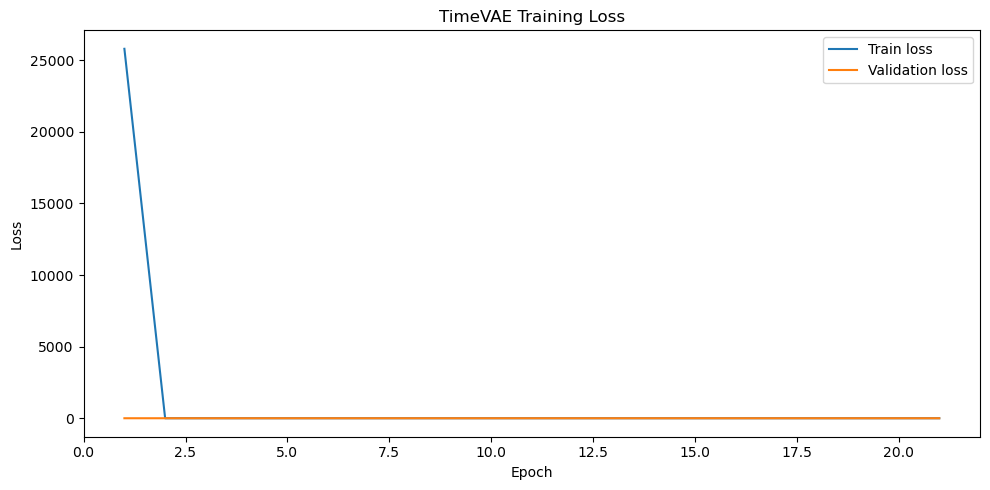

2026-06-14 23:07:11 | INFO | Saved/overwritten loss plot: /home/iailab42/khans1/projects/figures/timevae/timevae_training_loss.png


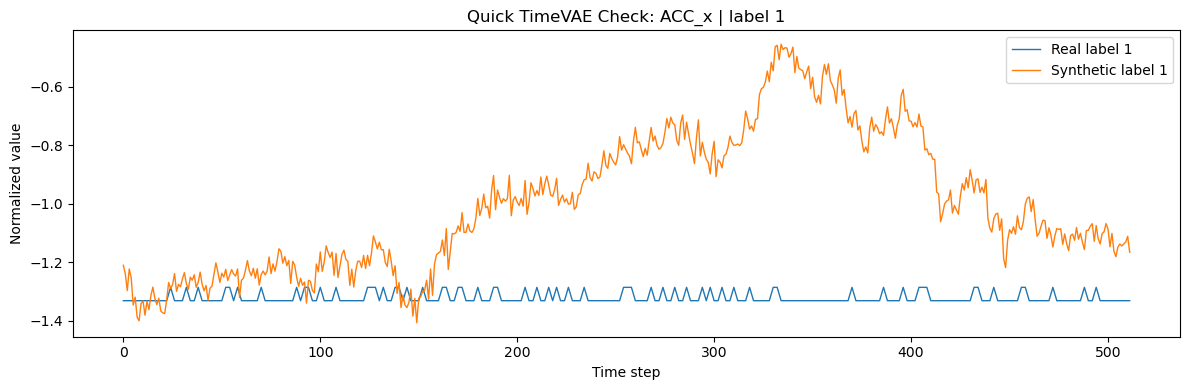

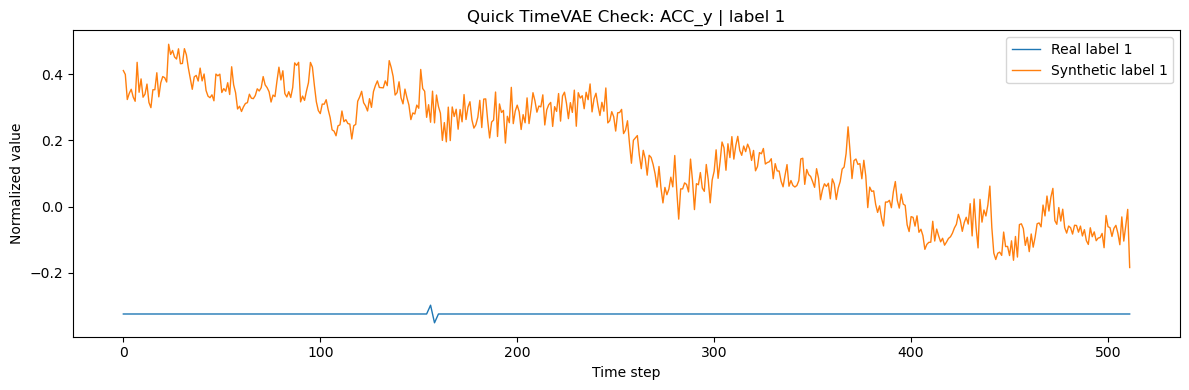

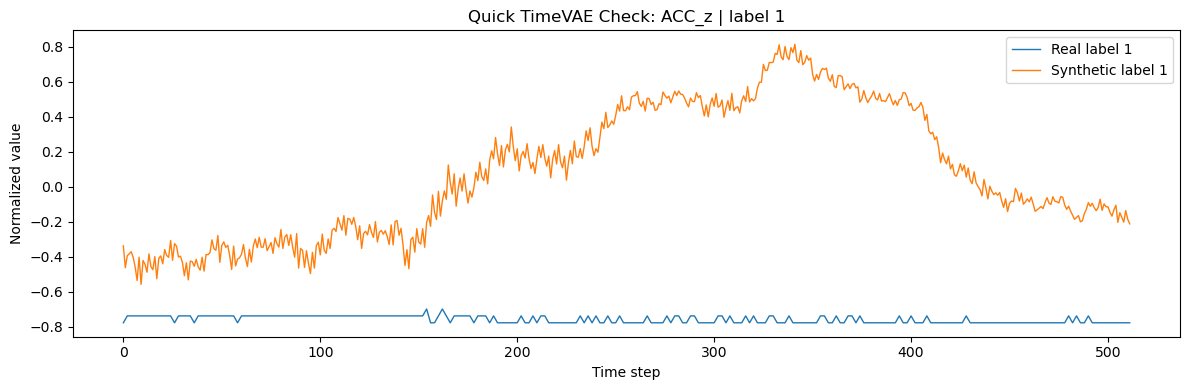

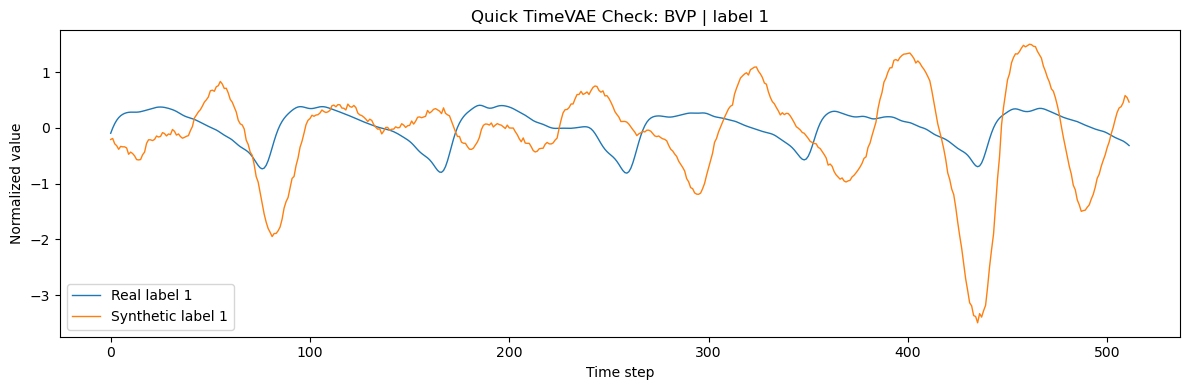

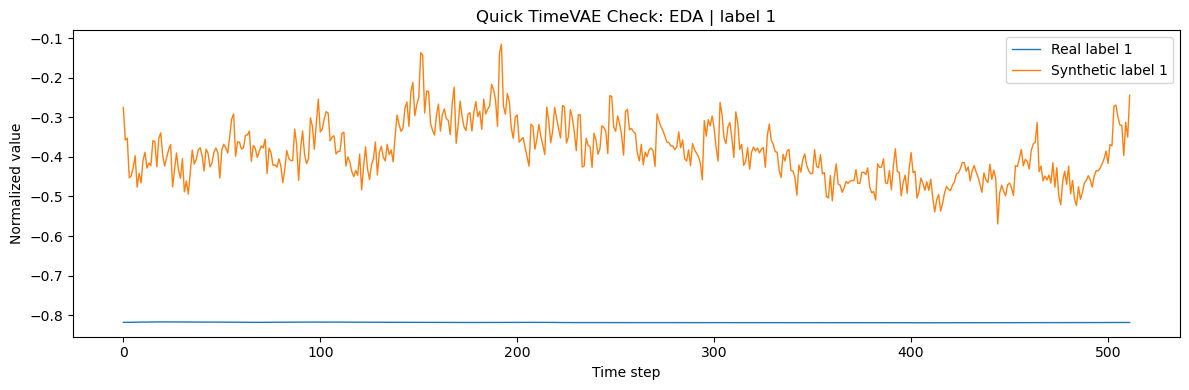

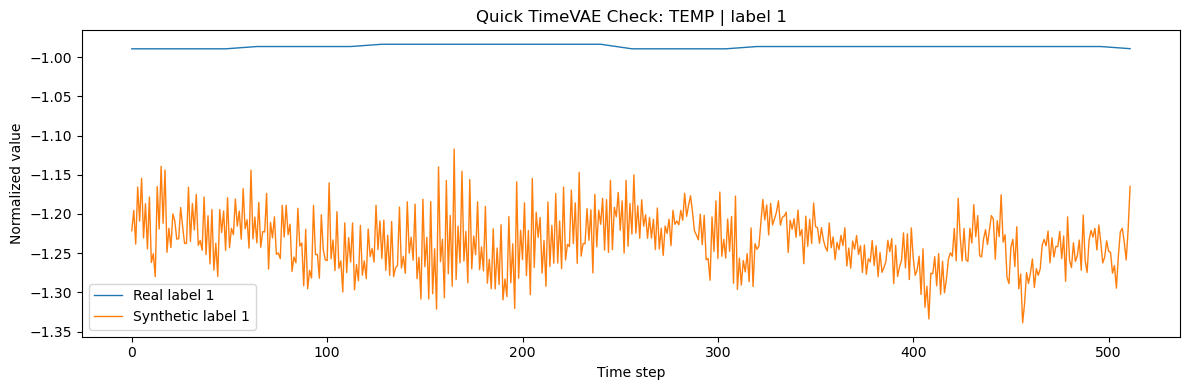

2026-06-14 23:07:12 | INFO | Saved/overwritten quick diagnostic plots in: /home/iailab42/khans1/projects/figures/timevae


In [115]:
def save_training_loss_plot(
    checkpoint: Dict[str, Any],
    paths: Dict[str, Path],
    logger: logging.Logger,
) -> None:
    history = checkpoint.get("history", [])

    if len(history) == 0:
        logger.warning("No training history found. Skipping training loss plot.")
        return

    history_df = pd.DataFrame(history)

    plt.figure(figsize=(10, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("TimeVAE Training Loss")
    plt.legend()
    plt.tight_layout()

    output_path = paths["figures_dir"] / "timevae_training_loss.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    plt.close()

    logger.info(f"Saved/overwritten loss plot: {output_path}")


def save_real_vs_synthetic_quick_plot(
    X_real: np.ndarray,
    X_syn: np.ndarray,
    y_real: np.ndarray,
    y_syn: np.ndarray,
    config: Dict[str, Any],
    paths: Dict[str, Path],
    logger: logging.Logger,
) -> None:
    if not config["outputs"]["save_diagnostic_plots"]:
        logger.info("Diagnostic plot saving disabled.")
        return

    rng = np.random.default_rng(config["seed"])

    y_real = np.asarray(y_real).astype(int)
    y_syn = np.asarray(y_syn).astype(int)

    common_labels = sorted(set(y_real.tolist()).intersection(set(y_syn.tolist())))

    if len(common_labels) == 0:
        raise ValueError("No common labels found between real and synthetic data.")

    # Pick one common activity label for a quick visual check.
    selected_label = int(rng.choice(common_labels))

    real_label_indices = np.where(y_real == selected_label)[0]
    syn_label_indices = np.where(y_syn == selected_label)[0]

    real_idx = int(rng.choice(real_label_indices))
    syn_idx = int(rng.choice(syn_label_indices))

    channel_names = config["data"]["channel_names"]

    for channel_idx, channel_name in enumerate(channel_names):
        plt.figure(figsize=(12, 4))

        plt.plot(
            X_real[real_idx, :, channel_idx],
            label=f"Real label {selected_label}",
            linewidth=1.0,
        )

        plt.plot(
            X_syn[syn_idx, :, channel_idx],
            label=f"Synthetic label {selected_label}",
            linewidth=1.0,
        )

        plt.xlabel("Time step")
        plt.ylabel("Normalized value")
        plt.title(f"Quick TimeVAE Check: {channel_name} | label {selected_label}")
        plt.legend()
        plt.tight_layout()

        output_path = paths["figures_dir"] / f"quick_real_vs_synthetic_{channel_name}.png"
        plt.savefig(output_path, dpi=150)
        plt.show()
        plt.close()

    logger.info(f"Saved/overwritten quick diagnostic plots in: {paths['figures_dir']}")


save_training_loss_plot(
    checkpoint=checkpoint,
    paths=PATHS,
    logger=logger,
)

save_real_vs_synthetic_quick_plot(
    X_real=X_real,
    X_syn=X_syn,
    y_real=normalize_label_array(y_real),
    y_syn=y_syn,
    config=CONFIG,
    paths=PATHS,
    logger=logger,
)

### Cell 17 — Final Output

In [116]:
print("=" * 70)
print("TimeVAE baseline finished.")

print("\nReal data folder:")
print(PATHS["real_data_dir"])

print("\nTimeVAE synthetic data folder:")
print(PATHS["synthetic_dir"])

print("\nModel file:")
print(PATHS["model_file"])

print("\nFriend-compatible synthetic files:")
for filename in [
    "all_X_synthetic.npy",
    "all_y_synthetic.npy",
    "all_y_internal_synthetic.npy",
    "all_subject_synthetic.npy",
    "all_metadata_synthetic.csv",
]:
    path = PATHS["synthetic_dir"] / filename
    print(f"{filename}: {path.exists()} | {path}")

print("\nSynthetic shape:")
print("X_syn:", X_syn.shape)
print("y_syn:", y_syn.shape)
print("y_internal_syn:", y_internal_syn.shape)
print("subject_syn:", subject_syn.shape)

print("\nSynthetic label counts:")
print(pd.Series(y_syn).value_counts().sort_index())

print("\nSynthetic subject examples:")
print(sorted(pd.Series(subject_syn.astype(str)).unique().tolist())[:10])

print("\nUse this synthetic directory in your friend's comparison code:")
print(PATHS["synthetic_dir"])

TimeVAE baseline finished.

Real data folder:
/home/iailab42/khans1/projects/data

TimeVAE synthetic data folder:
/home/iailab42/khans1/projects/data/synthetic/timevae

Model file:
/home/iailab42/khans1/projects/models/timevae/timevae_conditional_6ch.pt

Friend-compatible synthetic files:
all_X_synthetic.npy: True | /home/iailab42/khans1/projects/data/synthetic/timevae/all_X_synthetic.npy
all_y_synthetic.npy: True | /home/iailab42/khans1/projects/data/synthetic/timevae/all_y_synthetic.npy
all_y_internal_synthetic.npy: True | /home/iailab42/khans1/projects/data/synthetic/timevae/all_y_internal_synthetic.npy
all_subject_synthetic.npy: True | /home/iailab42/khans1/projects/data/synthetic/timevae/all_subject_synthetic.npy
all_metadata_synthetic.csv: True | /home/iailab42/khans1/projects/data/synthetic/timevae/all_metadata_synthetic.csv

Synthetic shape:
X_syn: (46907, 512, 6)
y_syn: (46907,)
y_internal_syn: (46907,)
subject_syn: (46907,)

Synthetic label counts:
1     4534
2     3205
3    